Environment ready!
NumPy: 2.4.3
pandas: 3.0.2
scikit-learn: 1.8.0


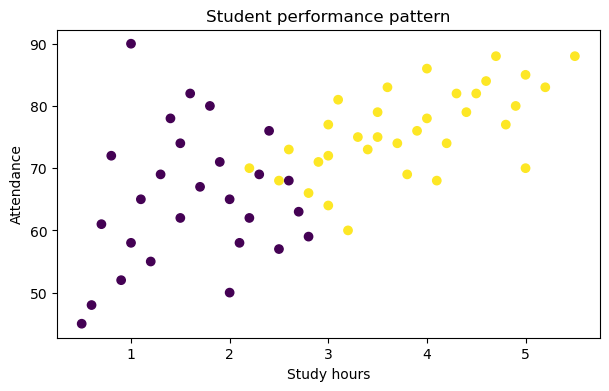

X shape: (60, 3)
y shape: (60,)
Training rows: 48
Testing rows : 12
Model trained!


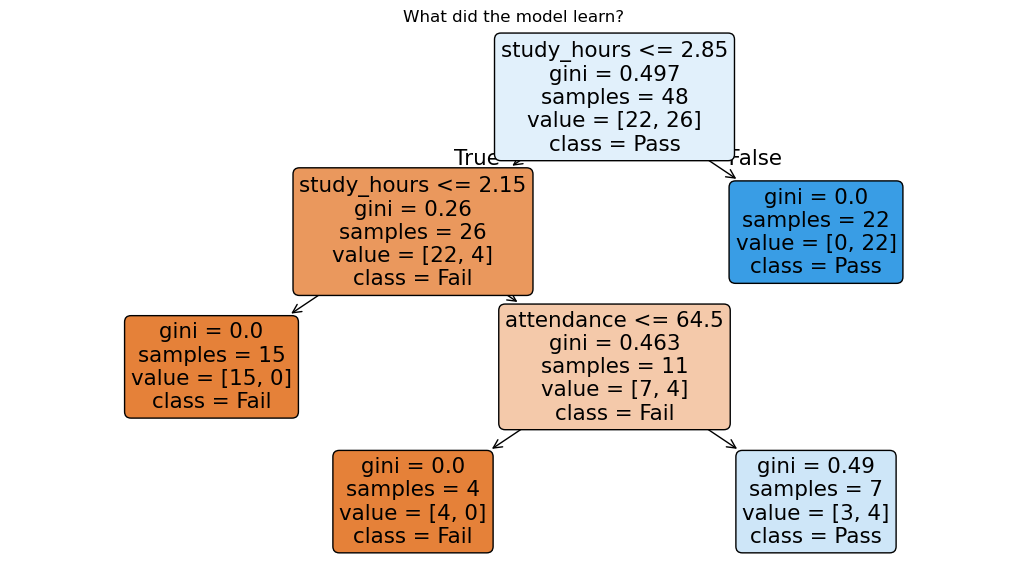

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)


df = pd.read_csv("student_performance.csv")
df.head()

df.groupby("result")[["study_hours","attendance","assignments"]].mean()
plt.figure(figsize=(7,4))
plt.scatter(df["study_hours"], df["attendance"], c=df["result"])
plt.xlabel("Study hours")
plt.ylabel("Attendance")
plt.title("Student performance pattern")
plt.show()



X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]



print("X shape:", X.shape)
print("y shape:", y.shape)



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")
plt.figure(figsize=(13,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)
plt.title("What did the model learn?")
plt.show()

In [4]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# =====================================================================
# STEP 1: Prepare Sample Data (In-Memory Dataset)
# =====================================================================
# We define simple email subjects and label them as 0 (Ham/Safe) or 1 (Spam)
emails = [
    "Meeting schedule for tomorrow project review",  # Safe (0)
    "WIN FREE CASH NOW! CLICK HERE!",  # Spam (1)
    "Please send the engineering lab report by Friday",  # Safe (0)
    "Claim your free prize money today",  # Spam (1)
    "Urgent account verification required",  # Safe (0)
    "CONGRATULATIONS! You won a brand new car",  # Spam (1)
]

labels = [0, 1, 0, 1, 0, 1]  # 0 = Normal Email, 1 = Spam Email

# =====================================================================
# STEP 2: Feature Extraction (Convert Text to Numbers)
# =====================================================================
# Machine Learning algorithms work on numbers, not raw text.
# CountVectorizer counts how many times each word appears in each email.
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)

# =====================================================================
# STEP 3: Train the Machine Learning Model
# =====================================================================
# We use Naive Bayes, a classic, fast algorithm for text classification.
model = MultinomialNB()
model.fit(X, labels)

print("--- Model Training Complete! ---\n")

# =====================================================================
# STEP 4: Test the Model on Unseen Email Subjects
# =====================================================================
new_emails = [
    "Submit your lab assignment tomorrow",  # Expected: Safe
    "Win a free prize and cash bonus now",  # Expected: Spam
]

# Convert new text to the exact same numerical format
X_new = vectorizer.transform(new_emails)

# Make predictions
predictions = model.predict(X_new)

# Display Results
for email, pred in zip(new_emails, predictions):
    status = "SPAM 🚨" if pred == 1 else "SAFE / NORMAL 🟢"
    print(f"Email   : '{email}'")
    print(f"Result  : {status}\n")

--- Model Training Complete! ---

Email   : 'Submit your lab assignment tomorrow'
Result  : SAFE / NORMAL 🟢

Email   : 'Win a free prize and cash bonus now'
Result  : SPAM 🚨



First 5 rows:
   Study_Hours  Attendance  Previous_Marks  Assignment_Score  Internal_Marks  \
0            7          61              41                87              86   
1            4          83              67                64              61   
2            8          82              93                74              62   
3            5          97              62                64              41   
4            7          72              76                68              66   

  Performance  
0        Pass  
1        Fail  
2        Pass  
3        Fail  
4        Pass  

--------------------------------
Decision Tree with max_depth = 3
--------------------------------
Accuracy: 90.0 %

Confusion Matrix:
[[ 4  1]
 [ 1 14]]

--------------------------------
Decision Tree with max_depth = 4
--------------------------------
Accuracy: 90.0 %

Confusion Matrix:
[[ 4  1]
 [ 1 14]]

--------------------------------
Decision Tree with max_depth = 5
--------------------------------

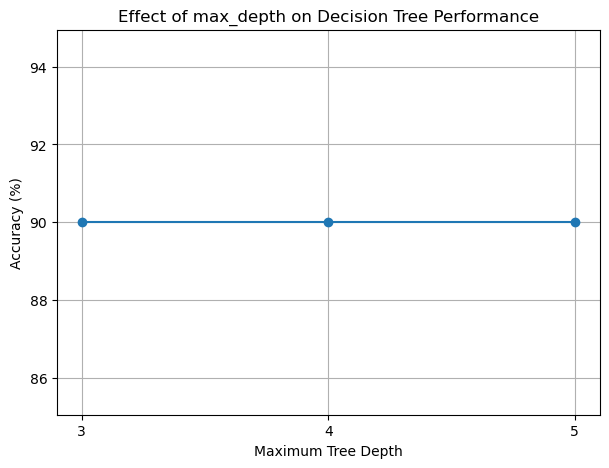

In [5]:
# Assignment 1
# Decision Tree for Student Performance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --------------------------------------------------
# 1. Create Student Dataset
# --------------------------------------------------

np.random.seed(42)

n = 100

data = {
    "Study_Hours": np.random.randint(1, 11, n),
    "Attendance": np.random.randint(50, 101, n),
    "Previous_Marks": np.random.randint(40, 96, n),
    "Assignment_Score": np.random.randint(40, 101, n),
    "Internal_Marks": np.random.randint(40, 96, n)
}

df = pd.DataFrame(data)

# Create performance score
score = (
    df["Study_Hours"] * 3 +
    df["Attendance"] * 0.2 +
    df["Previous_Marks"] * 0.3 +
    df["Assignment_Score"] * 0.2 +
    df["Internal_Marks"] * 0.3
)

# Create target
df["Performance"] = np.where(score >= 80, "Pass", "Fail")

print("First 5 rows:")
print(df.head())

# --------------------------------------------------
# 2. Separate Features and Target
# --------------------------------------------------

X = df[
    [
        "Study_Hours",
        "Attendance",
        "Previous_Marks",
        "Assignment_Score",
        "Internal_Marks"
    ]
]

y = df["Performance"]

# --------------------------------------------------
# 3. Split Dataset
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# 4. Train Decision Trees with different depths
# --------------------------------------------------

depths = [3, 4, 5]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Max Depth": depth,
        "Accuracy": accuracy
    })

    print("\n--------------------------------")
    print("Decision Tree with max_depth =", depth)
    print("--------------------------------")

    print("Accuracy:", round(accuracy * 100, 2), "%")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# --------------------------------------------------
# 5. Comparative Analysis
# --------------------------------------------------

results_df = pd.DataFrame(results)

print("\n\nComparison of Models:")
print(results_df)

# --------------------------------------------------
# 6. Plot Comparison
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    results_df["Max Depth"],
    results_df["Accuracy"] * 100,
    marker="o"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy (%)")
plt.title("Effect of max_depth on Decision Tree Performance")
plt.xticks([3, 4, 5])
plt.grid(True)

plt.show()

Electronics Dataset:
    Temperature  Power_Consumption
0            20                 50
1            22                 53
2            24                 56
3            26                 60
4            28                 63
5            30                 67
6            32                 70
7            34                 74
8            36                 77
9            38                 81
10           40                 84
11           42                 88
12           44                 91
13           46                 95
14           48                 98

Actual Values:
[81 88 50]

Predicted Values:
[80.68 87.65 49.32]

Slope: 1.7423943105491901
Intercept: 14.46819438956934

Regression Equation:
Power Consumption = 14.47 + 1.74 * Temperature

Model Evaluation:
MAE : 0.45
MSE : 0.23
RMSE: 0.48
R2 Score: 0.999


/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



Predicted power consumption at 35°C: 75.45


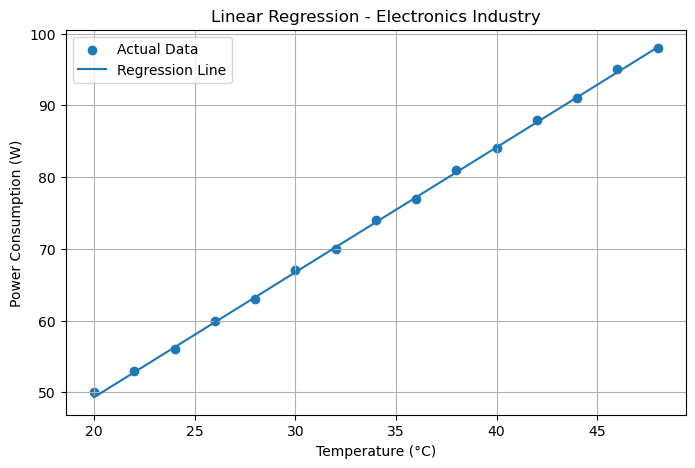

In [6]:
# Assignment 2
# Linear Regression in Electronics Industry

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------
# 1. Create Electronics Dataset
# --------------------------------------------------

data = {
    "Temperature": [
        20, 22, 24, 26, 28,
        30, 32, 34, 36, 38,
        40, 42, 44, 46, 48
    ],

    "Power_Consumption": [
        50, 53, 56, 60, 63,
        67, 70, 74, 77, 81,
        84, 88, 91, 95, 98
    ]
}

df = pd.DataFrame(data)

print("Electronics Dataset:")
print(df)

# --------------------------------------------------
# 2. Define X and Y
# --------------------------------------------------

X = df[["Temperature"]]
y = df["Power_Consumption"]

# --------------------------------------------------
# 3. Split Dataset
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# --------------------------------------------------
# 4. Create Linear Regression Model
# --------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)

# --------------------------------------------------
# 5. Make Predictions
# --------------------------------------------------

y_pred = model.predict(X_test)

print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(np.round(y_pred, 2))

# --------------------------------------------------
# 6. Model Equation
# --------------------------------------------------

print("\nSlope:", model.coef_[0])
print("Intercept:", model.intercept_)

print(
    "\nRegression Equation:"
)

print(
    "Power Consumption =",
    round(model.intercept_, 2),
    "+",
    round(model.coef_[0], 2),
    "* Temperature"
)

# --------------------------------------------------
# 7. Evaluate Model
# --------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 3))

# --------------------------------------------------
# 8. Predict Power for New Temperature
# --------------------------------------------------

new_temperature = [[35]]

prediction = model.predict(new_temperature)

print(
    "\nPredicted power consumption at 35°C:",
    round(prediction[0], 2)
)

# --------------------------------------------------
# 9. Visualization
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    y,
    label="Actual Data"
)

plt.plot(
    X,
    model.predict(X),
    label="Regression Line"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Power Consumption (W)")
plt.title("Linear Regression - Electronics Industry")

plt.legend()
plt.grid(True)

plt.show()

Customer Dataset:
    Annual_Income  Spending_Score
0              15              80
1              16              85
2              17              78
3              18              82
4              20              75
5              25              60
6              27              65
7              28              58
8              30              62
9              32              55
10             50              40
11             52              45
12             55              42
13             58              38
14             60              35
15             70              20
16             72              25
17             75              18
18             78              22
19             80              15


/lib/python3.14/site-packages/threadpoolctl.py:1135: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():



Customer Data with Cluster:
    Annual_Income  Spending_Score  Cluster
0              15              80        1
1              16              85        1
2              17              78        1
3              18              82        1
4              20              75        1
5              25              60        1
6              27              65        1
7              28              58        1
8              30              62        1
9              32              55        1
10             50              40        2
11             52              45        2
12             55              42        2
13             58              38        2
14             60              35        2
15             70              20        0
16             72              25        0
17             75              18        0
18             78              22        0
19             80              15        0

Cluster Centers:
[[75.  20. ]
 [22.8 70. ]
 [55.  40. ]]


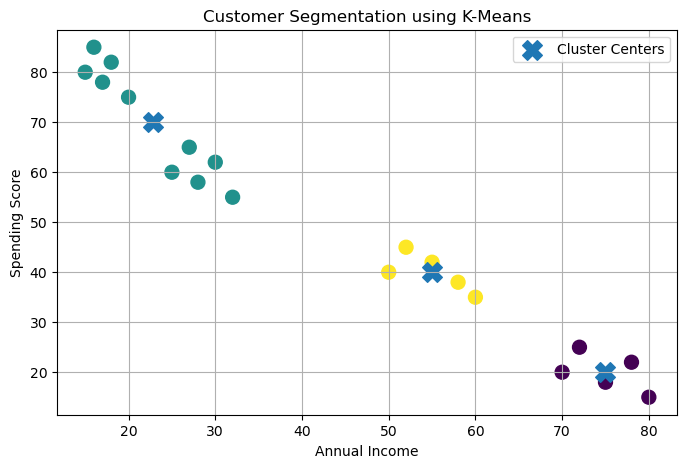

In [7]:
# Assignment 3
# Unsupervised Learning using K-Means Clustering

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

# --------------------------------------------------
# 1. Create Customer Dataset
# --------------------------------------------------

data = {
    "Annual_Income": [
        15, 16, 17, 18, 20,
        25, 27, 28, 30, 32,
        50, 52, 55, 58, 60,
        70, 72, 75, 78, 80
    ],

    "Spending_Score": [
        80, 85, 78, 82, 75,
        60, 65, 58, 62, 55,
        40, 45, 42, 38, 35,
        20, 25, 18, 22, 15
    ]
}

df = pd.DataFrame(data)

print("Customer Dataset:")
print(df)

# --------------------------------------------------
# 2. Select Features
# --------------------------------------------------

X = df[
    [
        "Annual_Income",
        "Spending_Score"
    ]
]

# --------------------------------------------------
# 3. Create K-Means Model
# --------------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# --------------------------------------------------
# 4. Train Model
# --------------------------------------------------

kmeans.fit(X)

# --------------------------------------------------
# 5. Assign Cluster Labels
# --------------------------------------------------

df["Cluster"] = kmeans.labels_

print("\nCustomer Data with Cluster:")
print(df)

# --------------------------------------------------
# 6. Display Cluster Centers
# --------------------------------------------------

print("\nCluster Centers:")

print(kmeans.cluster_centers_)

# --------------------------------------------------
# 7. Visualize Clusters
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"],
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    label="Cluster Centers"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")

plt.legend()
plt.grid(True)

plt.show()